# [WICS Company's Sector 분석](./docs/wics_company.md) 
> 중분류(IDX_NM_KOR) 기반 분기별 통합 성장률 Top 10 및 주도 종목 분석

- 데이터: 2021년 ~ 2026년 (WICS Sector Data)
- **분석 목표**: 대분류의 포괄적인 한계를 극복하고, 28개 **중분류 섹터(IDX_NM_KOR)**의 분기별 성장률(QoQ)을 정밀 타겟팅하여 가장 크게 성장한 Top 10 중분류 산업을 도출합니다.
- **필터링 조건**: 초소형 테마주의 통계 왜곡을 피하기 위해 **전 분기 시가총액 상위 200위 이내 기업**만을 집계 대상으로 합니다.
- **종목 분산 분석**: 이렇게 추출된 10개의 중분류 섹터 내에서, 시장 성장을 주도한 **대장주 1개씩 총 10개**를 추출하여 소속 산업의 성장률과 나란히 비교합니다.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import numpy as np

# 한글 폰트 설정
import koreanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

files = sorted(glob.glob('./data/csv/wics_company_*.zip') + glob.glob('./data/csv/wics_company_2026.csv'))
quarterly_data = {}

for f in files:
    if f.endswith('.zip'):
        df_full = pd.read_csv(f)
    else:
        df_full = pd.read_csv(f, encoding='utf-8')
        
    df_full['DATE'] = pd.to_datetime(df_full['DATE'].astype(str), format='%Y%m%d')
    df_full['Q'] = df_full['DATE'].dt.to_period('Q')
    
    # 각 분기별 마지막 DATE 구하기
    q_max_dates = df_full.groupby('Q')['DATE'].max()
    
    for q, max_date in q_max_dates.items():
        df_q = df_full[df_full['DATE'] == max_date].copy()
        
        # MKT_VAL 처리
        if df_q['MKT_VAL'].dtype == 'O':
            df_q['MKT_VAL'] = pd.to_numeric(df_q['MKT_VAL'].str.replace(',', ''), errors='coerce')
        
        df_q['CMP_CD'] = df_q['CMP_CD'].astype(str).str.zfill(6)
        # 중분류 명칭 전처리 (WICS 접두사 제거)
        df_q['IDX_NM_KOR'] = df_q['IDX_NM_KOR'].str.replace('WICS ', '', regex=False)
            
        df_unique = df_q.drop_duplicates(subset=['CMP_CD'])
        quarterly_data[str(q)] = df_unique[['CMP_CD', 'CMP_KOR', 'IDX_NM_KOR', 'MKT_VAL']]
    
print("데이터 로딩 완료: ", list(quarterly_data.keys()))


데이터 로딩 완료:  ['2026Q1', '2021Q1', '2021Q2', '2021Q3', '2021Q4', '2022Q1', '2022Q2', '2022Q3', '2022Q4', '2023Q1', '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4']


In [2]:
def plot_midlevel_analysis(prev_qtr, curr_qtr):
    if prev_qtr not in quarterly_data or curr_qtr not in quarterly_data:
        print(f"{prev_qtr} 또는 {curr_qtr} 데이터가 없습니다.")
        return
    
    df_prev = quarterly_data[prev_qtr].copy()
    df_curr = quarterly_data[curr_qtr].copy()
    
    # 1. 중분류(IDX_NM_KOR)별 전체 성장률 (Market Cap 합계 기준)
    sec_prev = df_prev.groupby('IDX_NM_KOR')['MKT_VAL'].sum()
    sec_curr = df_curr.groupby('IDX_NM_KOR')['MKT_VAL'].sum()
    sec_growth = ((sec_curr - sec_prev) / sec_prev * 100).dropna().rename('Sector_Growth').reset_index()
    
    # 중분류 성장률 Top 10 추출
    top10_sectors = sec_growth.sort_values('Sector_Growth', ascending=False).head(10)
    top10_sector_names = top10_sectors['IDX_NM_KOR'].tolist()
    
    # 2. 전 분기 기준 Top 200 기업 필터링 (초소형 테마주 방지)
    top200_prev = df_prev.sort_values('MKT_VAL', ascending=False).head(200)
    
    # 3. 데이터 병합 (개별 종목 QoQ 성장률)
    merged = pd.merge(top200_prev, df_curr, on='CMP_CD', suffixes=('_prev', '_curr'))
    merged['Company_Growth'] = (merged['MKT_VAL_curr'] - merged['MKT_VAL_prev']) / merged['MKT_VAL_prev'] * 100
    merged['IDX_NM_KOR'] = merged['IDX_NM_KOR_curr']
    
    # Top 10 섹터에 속한 기업만 필터링
    filtered_merged = merged[merged['IDX_NM_KOR'].isin(top10_sector_names)]
    
    # 4. 각 Top 10 중분류 섹터별로 성장률이 가장 높은 대장주 1개씩 추출
    best_companies = []
    for sector in top10_sector_names:
        sector_companies = filtered_merged[filtered_merged['IDX_NM_KOR'] == sector]
        if not sector_companies.empty:
            best_company_row = sector_companies.sort_values('Company_Growth', ascending=False).iloc[0]
            best_companies.append(best_company_row)
            
    best_df = pd.DataFrame(best_companies)
    best_df = pd.merge(best_df, top10_sectors, on='IDX_NM_KOR', how='left')
    best_df['Alpha'] = best_df['Company_Growth'] - best_df['Sector_Growth']
    best_df = best_df.sort_values('Company_Growth', ascending=True) # Barh 정렬용
    
    # --- 시각화 1: 중분류 섹터 성장률 Top 10 ---
    plt.figure(figsize=(10, 4))
    sns.barplot(data=top10_sectors.sort_values('Sector_Growth', ascending=False), 
                x='Sector_Growth', y='IDX_NM_KOR', palette='viridis')
    plt.title(f"{prev_qtr} ➔ {curr_qtr} 산업 중분류 평균 성장률 Top 10", fontsize=14)
    plt.xlabel("섹터 성장률 (%)")
    plt.ylabel("")
    for i, val in enumerate(top10_sectors.sort_values('Sector_Growth', ascending=False)['Sector_Growth']):
        if val >= 0:
            plt.text(val + 0.5, i, f"+{val:.1f}%", va='center', fontweight='bold')
        else:
            plt.text(val - 0.5, i, f"{val:.1f}%", va='center', ha='right', fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # --- 시각화 2: 각 섹터별 1위 종목(대장주) DataFrame 출력 ---
    if not best_df.empty:
        plot_data = best_df[['CMP_KOR_curr', 'IDX_NM_KOR', 'Company_Growth', 'Sector_Growth', 'Alpha']].copy()
        
        # 성장률이 높은 순으로 정렬
        plot_data = plot_data.sort_values('Company_Growth', ascending=False).reset_index(drop=True)
        plot_data.columns = ['종목명', '소속 중분류', '종목 성장률(%)', '섹터 성장률(%)', '초과 달성(Alpha %p)']
        
        from IPython.display import display
        # Pandas DataFrame 스타일링
        styled_df = plot_data.style.format({
            '종목 성장률(%)': '{:+.2f}%',
            '섹터 성장률(%)': '{:+.2f}%',
            '초과 달성(Alpha %p)': '{:+.2f}%p'
        }).background_gradient(subset=['종목 성장률(%)'], cmap='coolwarm')
        
        display(styled_df)


### 2021Q1 ➔ 2021Q2 분석
- **산업 동향**: 이 시기에는 **가정용품과개인용품**, **에너지**, **교육서비스** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 주요 대장주 등의 종목이 크게 약진했습니다.

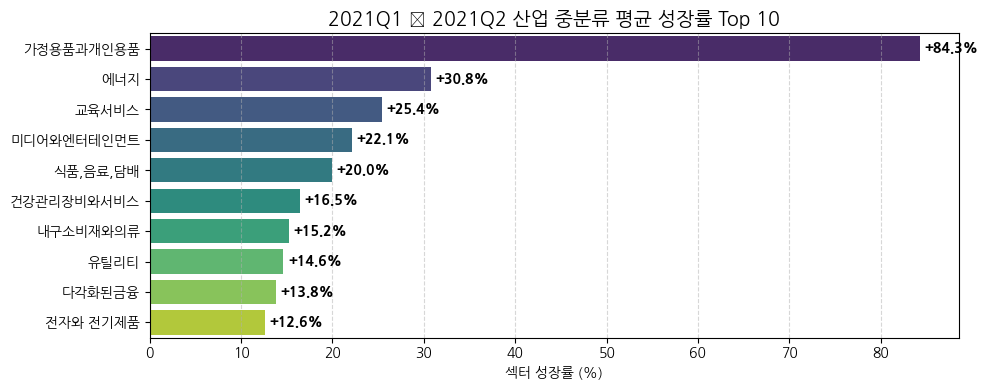

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,카카오,미디어와엔터테인먼트,+63.73%,+22.10%,+41.63%p
1,효성티앤씨,내구소비재와의류,+57.07%,+15.23%,+41.84%p
2,엘앤에프,전자와 전기제품,+43.38%,+12.62%,+30.75%p
3,SK이노베이션,에너지,+34.93%,+30.81%,+4.12%p
4,오스템임플란트(주),건강관리장비와서비스,+33.76%,+16.45%,+17.31%p
5,롯데지주,"식품,음료,담배",+18.24%,+19.98%,-1.74%p
6,한국가스공사,유틸리티,+9.50%,+14.63%,-5.14%p
7,삼성카드,다각화된금융,-0.44%,+13.81%,-14.24%p


In [3]:
plot_midlevel_analysis('2021Q1', '2021Q2')

### 2021Q2 ➔ 2021Q3 분석
- **산업 동향**: 이 시기에는 **건강관리장비와서비스**, **은행**, **부동산** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 **오스템임플란트(주)** 등의 종목이 크게 약진했습니다.

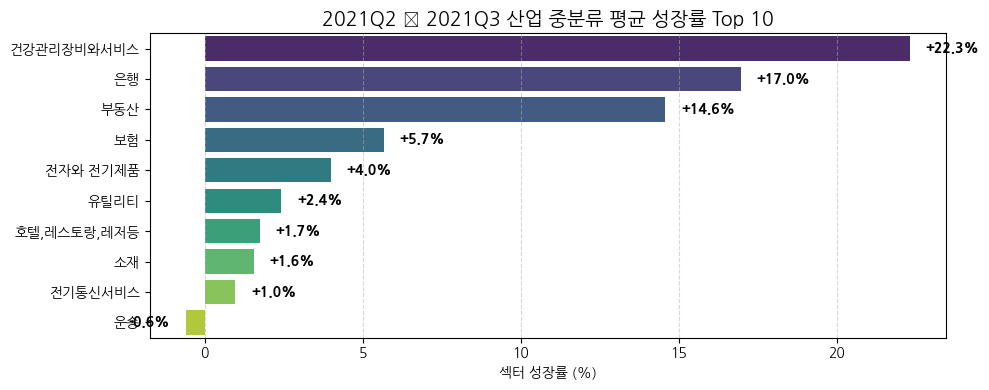

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,에코프로비엠,전자와 전기제품,+120.18%,+4.00%,+116.18%p
1,HS효성첨단소재,소재,+66.40%,+1.55%,+64.85%p
2,메리츠금융지주,보험,+58.73%,+5.66%,+53.07%p
3,아시아나항공,운송,+54.94%,-0.59%,+55.53%p
4,한국가스공사,유틸리티,+31.84%,+2.42%,+29.42%p
5,JB금융지주,은행,+18.59%,+16.96%,+1.63%p
6,오스템임플란트(주),건강관리장비와서비스,+17.77%,+22.31%,-4.55%p
7,강원랜드,"호텔,레스토랑,레저등",+6.51%,+1.74%,+4.77%p
8,KT,전기통신서비스,+2.52%,+0.97%,+1.55%p


In [4]:
plot_midlevel_analysis('2021Q2', '2021Q3')

### 2021Q3 ➔ 2021Q4 분석
- **산업 동향**: 이 시기에는 **소프트웨어와서비스**, **부동산**, **가정용품과개인용품** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 **삼성에스디에스** 등의 종목이 크게 약진했습니다.

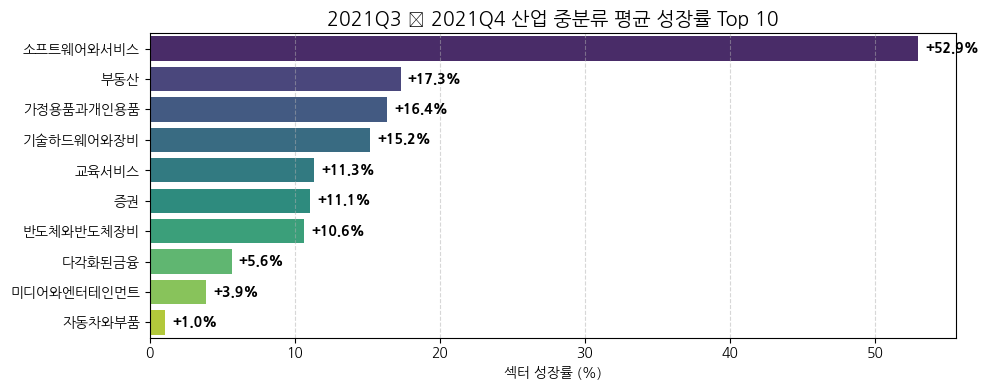

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,위메이드,미디어와엔터테인먼트,+154.64%,+3.89%,+150.75%p
1,LG이노텍,기술하드웨어와장비,+74.58%,+15.21%,+59.37%p
2,동진쎄미켐,반도체와반도체장비,+62.16%,+10.64%,+51.52%p
3,메리츠금융지주,증권,+30.76%,+11.07%,+19.69%p
4,HL만도,자동차와부품,+11.03%,+1.05%,+9.99%p
5,삼성에스디에스,소프트웨어와서비스,-2.49%,+52.93%,-55.42%p


In [5]:
plot_midlevel_analysis('2021Q3', '2021Q4')

### 2021Q4 ➔ 2022Q1 분석
- **산업 동향**: 이 시기에는 **식품과기본식료품소매**, **보험**, **교육서비스** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 주요 대장주 등의 종목이 크게 약진했습니다.

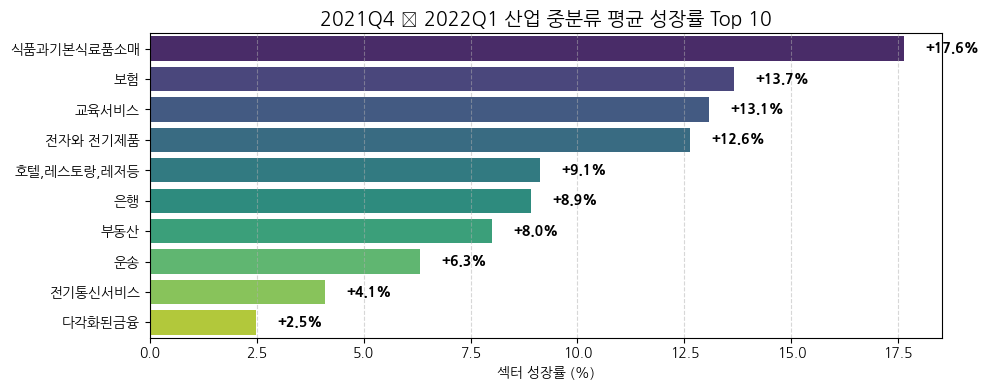

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,메리츠화재해상보험(주),보험,+41.43%,+13.65%,+27.78%p
1,팬오션,운송,+29.21%,+6.31%,+22.90%p
2,우리금융지주,은행,+20.87%,+8.91%,+11.96%p
3,KT,전기통신서비스,+16.67%,+4.10%,+12.57%p
4,강원랜드,"호텔,레스토랑,레저등",+15.80%,+9.11%,+6.69%p
5,엘앤에프,전자와 전기제품,+4.79%,+12.62%,-7.83%p


In [6]:
plot_midlevel_analysis('2021Q4', '2022Q1')

### 2022Q1 ➔ 2022Q2 분석
- **산업 동향**: 이 시기에는 **에너지**, **유틸리티**, **식품,음료,담배** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 **씨에스윈드** 등의 종목이 크게 약진했습니다.

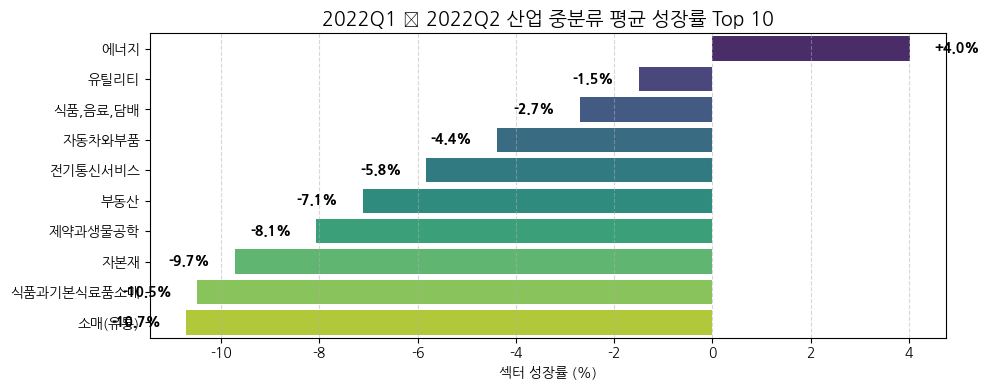

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,씨에스윈드,에너지,+37.98%,+4.01%,+33.97%p
1,한국항공우주,자본재,+27.19%,-9.72%,+36.90%p
2,HLB,제약과생물공학,+19.93%,-8.06%,+27.99%p
3,오리온,"식품,음료,담배",+17.12%,-2.70%,+19.82%p
4,롯데쇼핑,소매(유통),+8.56%,-10.71%,+19.27%p
5,기아,자동차와부품,+4.46%,-4.39%,+8.85%p
6,KT,전기통신서비스,+2.10%,-5.82%,+7.92%p
7,한국가스공사,유틸리티,-0.13%,-1.50%,+1.38%p


In [7]:
plot_midlevel_analysis('2022Q1', '2022Q2')

### 2022Q2 ➔ 2022Q3 분석
- **산업 동향**: 이 시기에는 **전자와 전기제품**, **식품,음료,담배**, **소재** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 **LG에너지솔루션** 등의 종목이 크게 약진했습니다.

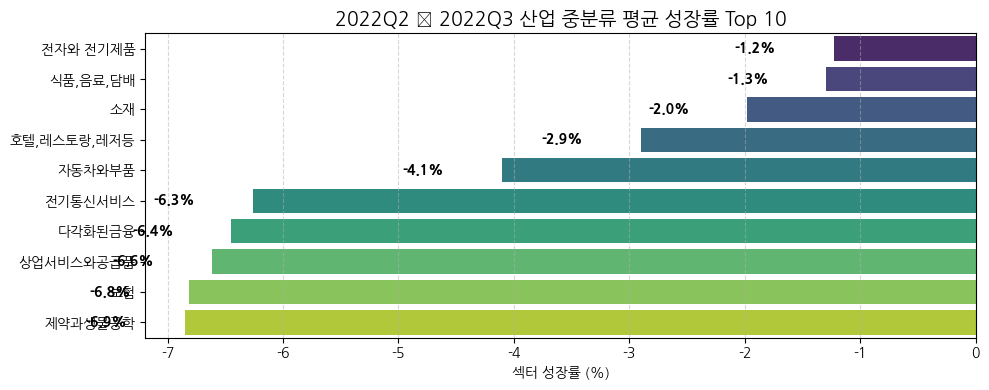

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,에코프로,소재,+65.56%,-1.98%,+67.54%p
1,HLB,제약과생물공학,+21.07%,-6.85%,+27.92%p
2,LG에너지솔루션,전자와 전기제품,+14.96%,-1.23%,+16.19%p
3,농심,"식품,음료,담배",+11.40%,-1.29%,+12.70%p
4,현대위아,자동차와부품,+7.71%,-4.11%,+11.81%p
5,호텔신라,"호텔,레스토랑,레저등",+0.98%,-2.90%,+3.88%p
6,삼성생명,보험,-0.32%,-6.82%,+6.50%p
7,KT,전기통신서비스,-0.69%,-6.26%,+5.58%p
8,삼성카드,다각화된금융,-0.98%,-6.45%,+5.47%p
9,에스원,상업서비스와공급품,-9.81%,-6.62%,-3.19%p


In [8]:
plot_midlevel_analysis('2022Q2', '2022Q3')

### 2022Q3 ➔ 2022Q4 분석
- **산업 동향**: 이 시기에는 **건강관리장비와서비스**, **증권**, **보험** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 **오스템임플란트(주)** 등의 종목이 크게 약진했습니다.

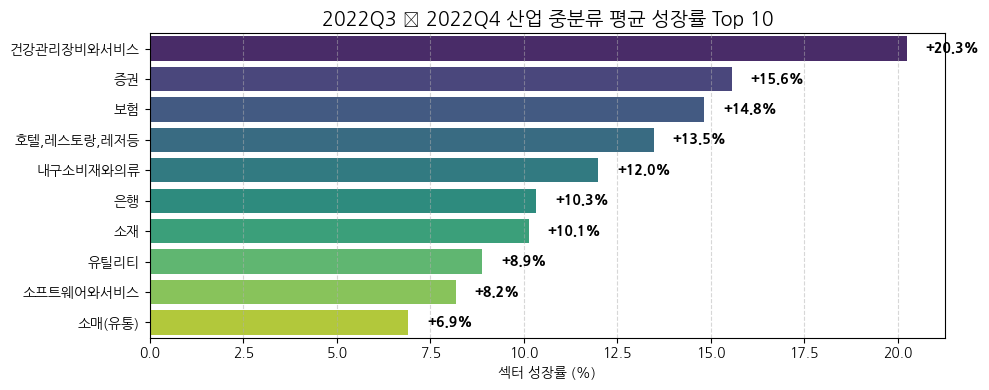

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,메리츠금융지주,증권,+104.80%,+15.57%,+89.23%p
1,메리츠화재해상보험(주),보험,+64.51%,+14.83%,+49.68%p
2,롯데케미칼,소재,+54.70%,+10.14%,+44.56%p
3,효성티앤씨,내구소비재와의류,+35.14%,+12.00%,+23.14%p
4,BGF리테일,소매(유통),+27.19%,+6.91%,+20.28%p
5,오스템임플란트(주),건강관리장비와서비스,+24.96%,+20.25%,+4.70%p
6,카카오뱅크,은행,+21.22%,+10.34%,+10.89%p
7,호텔신라,"호텔,레스토랑,레저등",+15.58%,+13.47%,+2.10%p
8,카카오페이,소프트웨어와서비스,+10.70%,+8.20%,+2.50%p
9,한국전력,유틸리티,+8.46%,+8.89%,-0.44%p


In [9]:
plot_midlevel_analysis('2022Q3', '2022Q4')

### 2022Q4 ➔ 2023Q1 분석
- **산업 동향**: 이 시기에는 **전자와 전기제품**, **디스플레이**, **소재** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 **에코프로비엠** 등의 종목이 크게 약진했습니다.

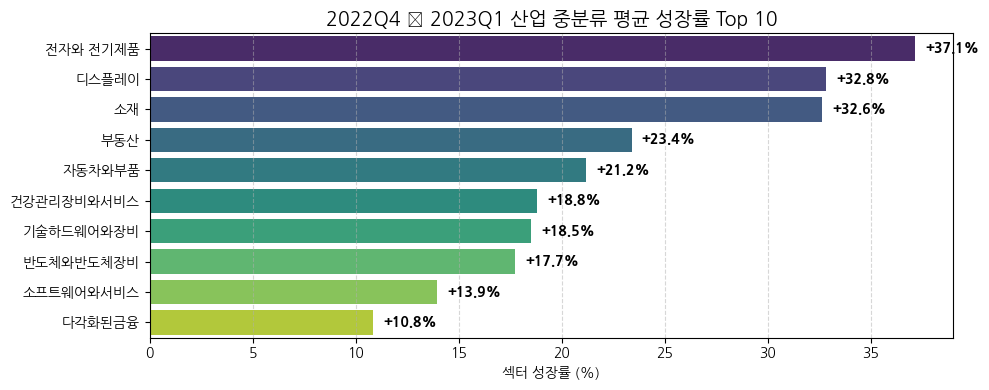

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,에코프로,소재,+394.94%,+32.62%,+362.32%p
1,에코프로비엠,전자와 전기제품,+143.76%,+37.14%,+106.62%p
2,DB하이텍,반도체와반도체장비,+94.62%,+17.73%,+76.88%p
3,LX세미콘,디스플레이,+56.21%,+32.82%,+23.38%p
4,대주전자재료,기술하드웨어와장비,+43.52%,+18.50%,+25.02%p
5,오스템임플란트(주),건강관리장비와서비스,+42.66%,+18.82%,+23.84%p
6,기아,자동차와부품,+36.59%,+21.18%,+15.42%p
7,카카오페이,소프트웨어와서비스,+3.11%,+13.93%,-10.82%p
8,삼성카드,다각화된금융,+2.88%,+10.84%,-7.96%p


In [10]:
plot_midlevel_analysis('2022Q4', '2023Q1')

### 2023Q1 ➔ 2023Q2 분석
- **산업 동향**: 이 시기에는 **가정용품과개인용품**, **건강관리장비와서비스**, **반도체와반도체장비** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 주요 대장주 등의 종목이 크게 약진했습니다.

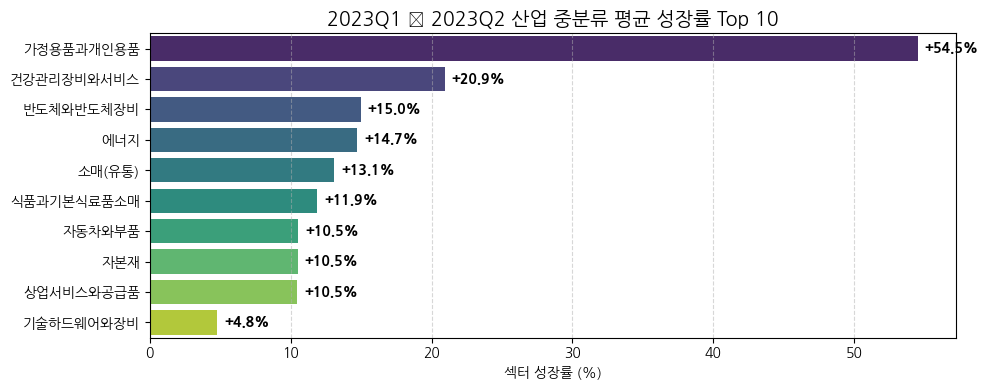

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,한화오션,자본재,+211.04%,+10.50%,+200.55%p
1,한미반도체,반도체와반도체장비,+45.65%,+14.96%,+30.69%p
2,대덕전자,기술하드웨어와장비,+36.08%,+4.79%,+31.29%p
3,현대위아,자동차와부품,+19.64%,+10.52%,+9.13%p
4,씨에스윈드,에너지,+18.38%,+14.74%,+3.65%p
5,덴티움,건강관리장비와서비스,+3.79%,+20.94%,-17.14%p
6,에스원,상업서비스와공급품,-3.62%,+10.45%,-14.07%p
7,BGF리테일,소매(유통),-3.74%,+13.11%,-16.85%p


In [11]:
plot_midlevel_analysis('2023Q1', '2023Q2')

### 2023Q2 ➔ 2023Q3 분석
- **산업 동향**: 이 시기에는 **보험**, **소프트웨어와서비스**, **은행** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 **DB손해보험** 등의 종목이 크게 약진했습니다.

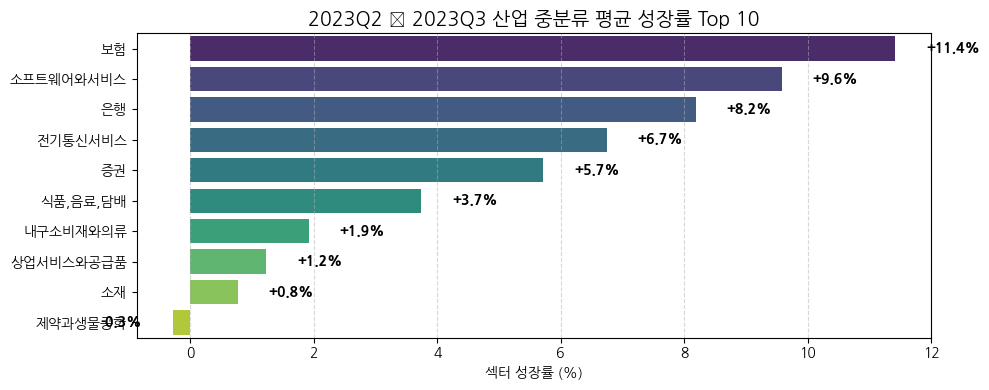

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,포스코DX,소프트웨어와서비스,+255.41%,+9.58%,+245.83%p
1,금양,소재,+126.55%,+0.77%,+125.79%p
2,알테오젠,제약과생물공학,+58.76%,-0.28%,+59.05%p
3,코스맥스,내구소비재와의류,+38.39%,+1.92%,+36.47%p
4,메리츠금융지주,증권,+33.01%,+5.72%,+27.29%p
5,메지온,"식품,음료,담배",+25.07%,+3.74%,+21.33%p
6,DB손해보험,보험,+19.84%,+11.42%,+8.42%p
7,JB금융지주,은행,+17.59%,+8.18%,+9.41%p
8,SK텔레콤,전기통신서비스,+11.59%,+6.74%,+4.84%p
9,에스원,상업서비스와공급품,+6.19%,+1.23%,+4.96%p


In [12]:
plot_midlevel_analysis('2023Q2', '2023Q3')

### 2023Q3 ➔ 2023Q4 분석
- **산업 동향**: 이 시기에는 **운송**, **제약과생물공학**, **소프트웨어와서비스** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 **한진칼** 등의 종목이 크게 약진했습니다.

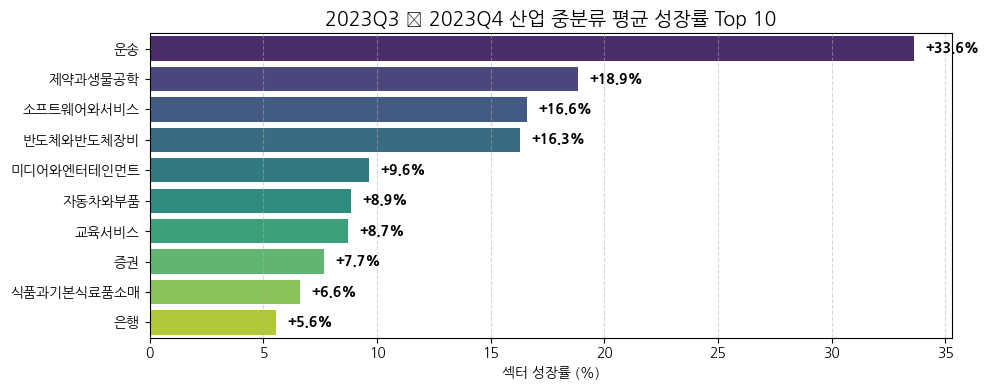

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,리가켐바이오,제약과생물공학,+81.50%,+18.85%,+62.65%p
1,한진칼,운송,+71.90%,+33.61%,+38.29%p
2,넷마블,미디어와엔터테인먼트,+38.00%,+9.65%,+28.36%p
3,포스코DX,소프트웨어와서비스,+36.90%,+16.62%,+20.28%p
4,솔브레인,반도체와반도체장비,+32.46%,+16.30%,+16.16%p
5,기아,자동차와부품,+22.85%,+8.86%,+13.99%p
6,카카오뱅크,은행,+22.07%,+5.56%,+16.51%p
7,미래에셋증권,증권,+18.29%,+7.66%,+10.64%p


In [13]:
plot_midlevel_analysis('2023Q3', '2023Q4')

### 2023Q4 ➔ 2024Q1 분석
- **산업 동향**: 이 시기에는 **은행**, **보험**, **증권** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 **하나금융지주** 등의 종목이 크게 약진했습니다.

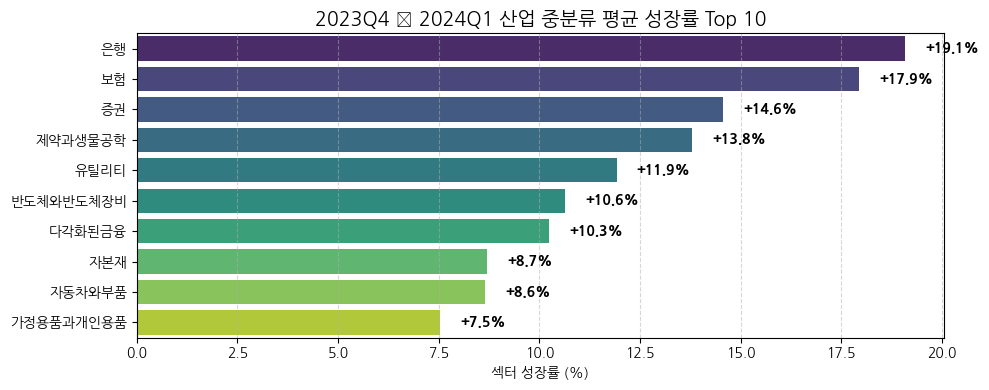

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,HD현대일렉트릭,자본재,+118.25%,+8.71%,+109.54%p
1,한미반도체,반도체와반도체장비,+116.69%,+10.64%,+106.05%p
2,HLB,제약과생물공학,+109.93%,+13.80%,+96.14%p
3,메리츠금융지주,증권,+38.24%,+14.57%,+23.67%p
4,삼성생명,보험,+33.57%,+17.94%,+15.64%p
5,하나금융지주,은행,+32.95%,+19.09%,+13.86%p
6,한국타이어앤테크놀로지,자동차와부품,+19.38%,+8.64%,+10.74%p
7,삼성카드,다각화된금융,+17.00%,+10.25%,+6.75%p
8,한국전력,유틸리티,+16.40%,+11.92%,+4.48%p


In [14]:
plot_midlevel_analysis('2023Q4', '2024Q1')

### 2024Q1 ➔ 2024Q2 분석
- **산업 동향**: 이 시기에는 **건강관리장비와서비스**, **자동차와부품**, **보험** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 **덴티움** 등의 종목이 크게 약진했습니다.

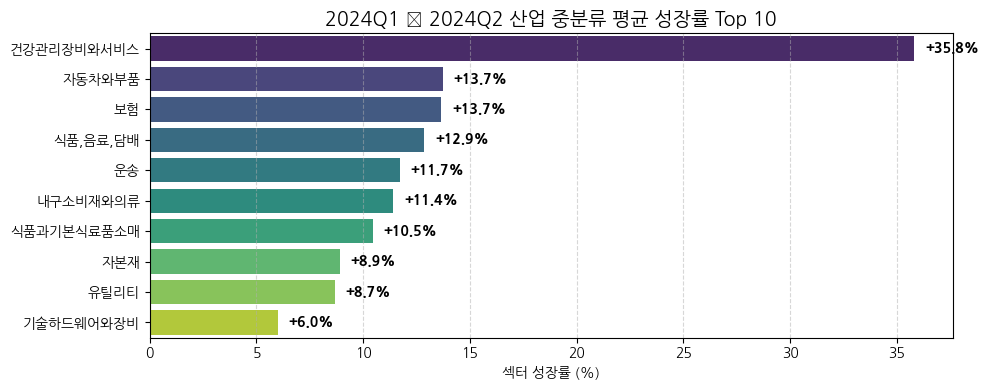

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,삼양식품,"식품,음료,담배",+217.81%,+12.87%,+204.95%p
1,LS ELECTRIC,자본재,+125.46%,+8.89%,+116.57%p
2,한국가스공사,유틸리티,+94.41%,+8.68%,+85.73%p
3,코스맥스,내구소비재와의류,+62.03%,+11.41%,+50.62%p
4,대주전자재료,기술하드웨어와장비,+54.26%,+6.00%,+48.26%p
5,HL만도,자동차와부품,+31.83%,+13.73%,+18.11%p
6,HMM,운송,+28.50%,+11.71%,+16.79%p
7,삼성화재,보험,+27.12%,+13.66%,+13.47%p
8,덴티움,건강관리장비와서비스,-12.95%,+35.83%,-48.78%p


In [15]:
plot_midlevel_analysis('2024Q1', '2024Q2')

### 2024Q2 ➔ 2024Q3 분석
- **산업 동향**: 이 시기에는 **제약과생물공학**, **건강관리장비와서비스**, **부동산** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 **유한양행** 등의 종목이 크게 약진했습니다.

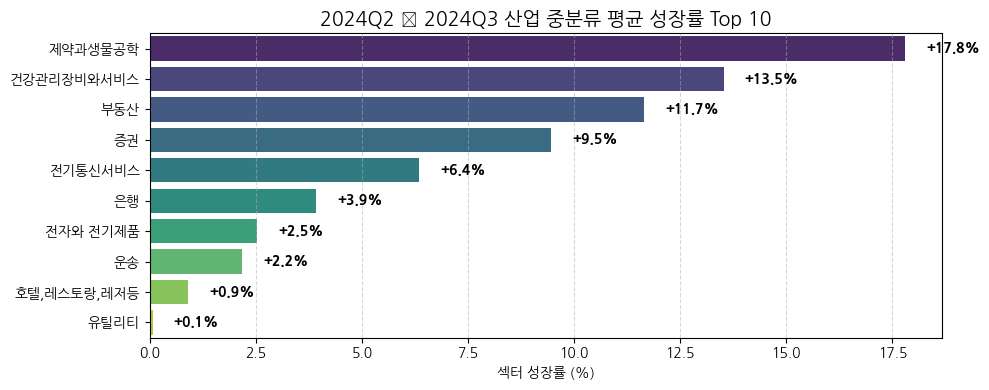

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,유한양행,제약과생물공학,+76.27%,+17.79%,+58.48%p
1,에코프로머티,전자와 전기제품,+48.40%,+2.53%,+45.88%p
2,HLB,건강관리장비와서비스,+46.81%,+13.52%,+33.29%p
3,한진칼,운송,+27.71%,+2.17%,+25.54%p
4,메리츠금융지주,증권,+22.76%,+9.45%,+13.30%p
5,강원랜드,"호텔,레스토랑,레저등",+22.26%,+0.91%,+21.36%p
6,신한지주,은행,+15.26%,+3.91%,+11.35%p
7,한전KPS,유틸리티,+10.94%,+0.07%,+10.87%p
8,SK텔레콤,전기통신서비스,+8.54%,+6.36%,+2.19%p


In [16]:
plot_midlevel_analysis('2024Q2', '2024Q3')

### 2024Q3 ➔ 2024Q4 분석
- **산업 동향**: 이 시기에는 **에너지**, **미디어와엔터테인먼트**, **교육서비스** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 **SK이노베이션** 등의 종목이 크게 약진했습니다.

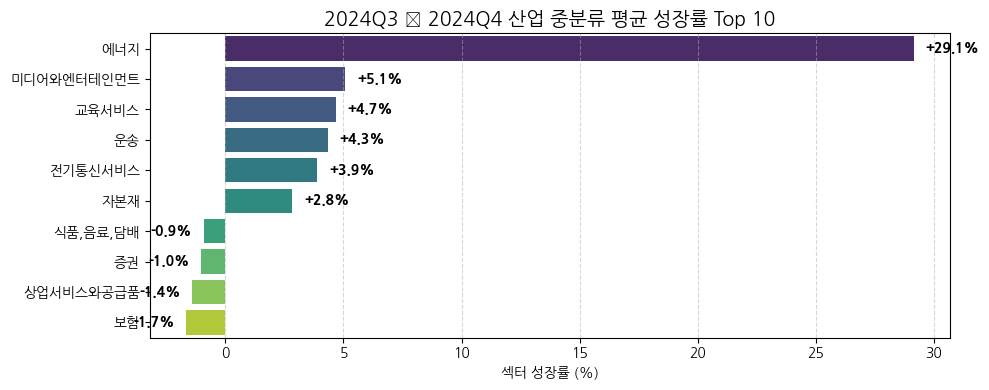

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,HD현대중공업,자본재,+55.74%,+2.84%,+52.90%p
1,SK이노베이션,에너지,+50.89%,+29.15%,+21.75%p
2,삼양식품,"식품,음료,담배",+40.88%,-0.90%,+41.79%p
3,JYP Ent.,미디어와엔터테인먼트,+38.69%,+5.08%,+33.61%p
4,코리안리,보험,+13.66%,-1.66%,+15.33%p
5,HMM,운송,+12.10%,+4.33%,+7.77%p
6,KT,전기통신서비스,+9.08%,+3.89%,+5.19%p
7,메리츠금융지주,증권,+7.11%,-1.02%,+8.12%p
8,에스원,상업서비스와공급품,+0.17%,-1.40%,+1.57%p


In [17]:
plot_midlevel_analysis('2024Q3', '2024Q4')

### 2024Q4 ➔ 2025Q1 분석
- **산업 동향**: 이 시기에는 **자본재**, **식품과기본식료품소매**, **반도체와반도체장비** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 **현대로템** 등의 종목이 크게 약진했습니다.

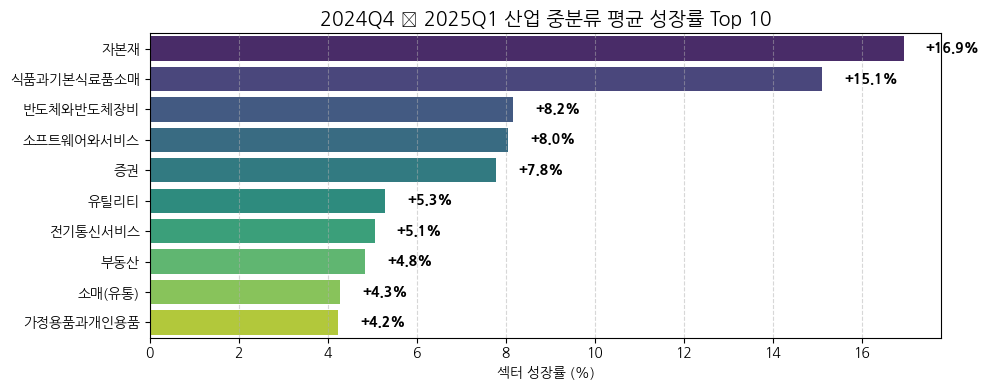

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,현대로템,자본재,+111.27%,+16.94%,+94.33%p
1,동진쎄미켐,반도체와반도체장비,+39.47%,+8.16%,+31.32%p
2,이마트,소매(유통),+27.92%,+4.28%,+23.64%p
3,포스코DX,소프트웨어와서비스,+27.88%,+8.04%,+19.84%p
4,메리츠금융지주,증권,+17.31%,+7.79%,+9.52%p
5,KT,전기통신서비스,+13.11%,+5.05%,+8.06%p
6,한국전력,유틸리티,+7.98%,+5.30%,+2.68%p


In [18]:
plot_midlevel_analysis('2024Q4', '2025Q1')

### 2025Q1 ➔ 2025Q2 분석
- **산업 동향**: 이 시기에는 **유틸리티**, **자본재**, **증권** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 **한국전력** 등의 종목이 크게 약진했습니다.

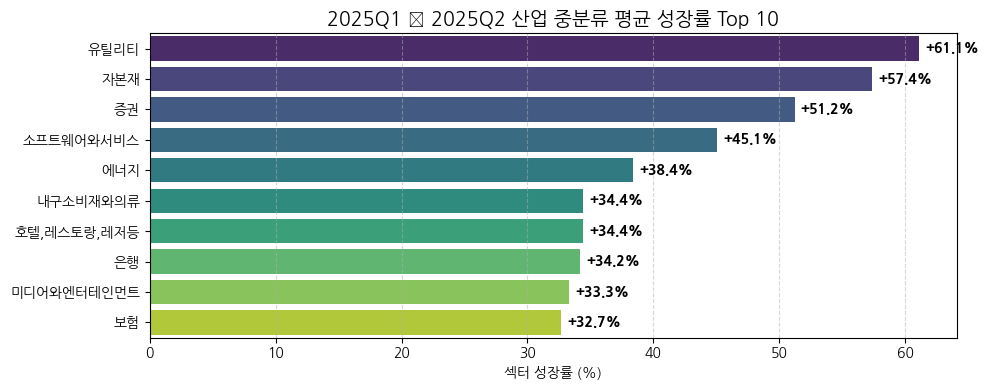

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,두산에너빌리티,자본재,+191.68%,+57.39%,+134.30%p
1,카카오페이,소프트웨어와서비스,+168.24%,+45.06%,+123.18%p
2,미래에셋증권,증권,+133.91%,+51.21%,+82.70%p
3,에이피알,내구소비재와의류,+125.68%,+34.45%,+91.23%p
4,한국전력,유틸리티,+81.52%,+61.07%,+20.46%p
5,HD현대,에너지,+78.62%,+38.37%,+40.25%p
6,넷마블,미디어와엔터테인먼트,+58.37%,+33.33%,+25.04%p
7,삼성생명,보험,+53.68%,+32.69%,+20.99%p
8,하나금융지주,은행,+43.53%,+34.17%,+9.36%p
9,강원랜드,"호텔,레스토랑,레저등",+9.84%,+34.43%,-24.58%p


In [19]:
plot_midlevel_analysis('2025Q1', '2025Q2')

### 2025Q2 ➔ 2025Q3 분석
- **산업 동향**: 이 시기에는 **반도체와반도체장비**, **디스플레이**, **기술하드웨어와장비** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 **원익IPS** 등의 종목이 크게 약진했습니다.

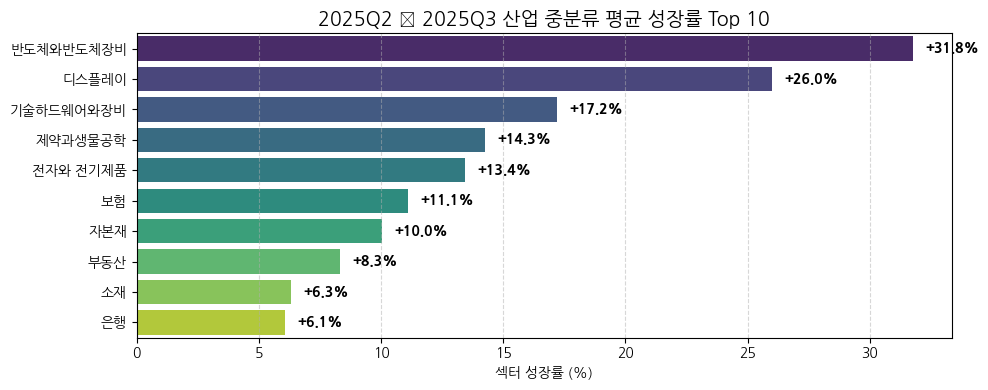

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,원익IPS,반도체와반도체장비,+77.69%,+31.76%,+45.93%p
1,디앤디파마텍,제약과생물공학,+70.18%,+14.25%,+55.93%p
2,LG디스플레이,디스플레이,+60.83%,+26.01%,+34.81%p
3,한화엔진,자본재,+57.82%,+10.04%,+47.78%p
4,엘앤에프,전자와 전기제품,+50.71%,+13.44%,+37.27%p
5,삼성전기,기술하드웨어와장비,+43.65%,+17.19%,+26.46%p
6,LG화학,소재,+31.44%,+6.33%,+25.12%p
7,삼성생명,보험,+22.92%,+11.10%,+11.82%p
8,BNK금융지주,은행,+15.73%,+6.06%,+9.67%p


In [20]:
plot_midlevel_analysis('2025Q2', '2025Q3')

### 2025Q3 ➔ 2025Q4 분석
- **산업 동향**: 이 시기에는 **반도체와반도체장비**, **부동산**, **전자와 전기제품** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 **SK하이닉스** 등의 종목이 크게 약진했습니다.

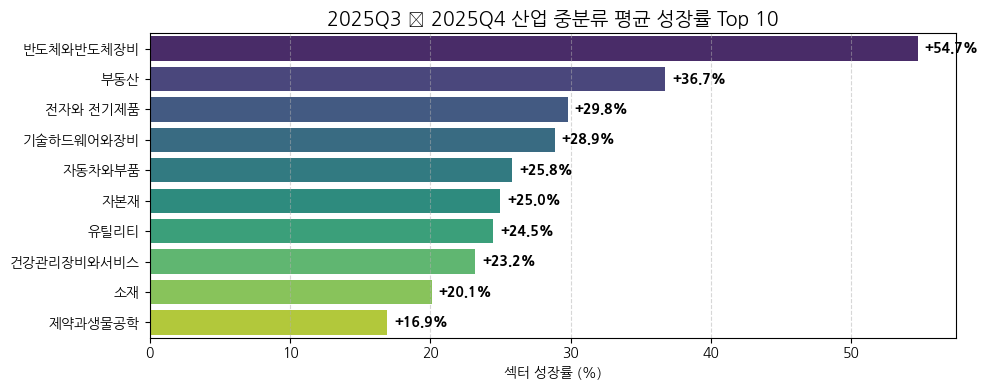

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,레인보우로보틱스,자본재,+141.83%,+24.95%,+116.88%p
1,에이비엘바이오,제약과생물공학,+137.92%,+16.92%,+121.00%p
2,이수페타시스,기술하드웨어와장비,+90.33%,+28.86%,+61.47%p
3,SK하이닉스,반도체와반도체장비,+87.34%,+54.73%,+32.61%p
4,HL만도,자동차와부품,+74.70%,+25.81%,+48.89%p
5,엘앤에프,전자와 전기제품,+72.26%,+29.79%,+42.47%p
6,에코프로,소재,+65.69%,+20.09%,+45.60%p
7,한전기술,유틸리티,+59.37%,+24.45%,+34.91%p
8,HLB,건강관리장비와서비스,+34.27%,+23.20%,+11.07%p


In [21]:
plot_midlevel_analysis('2025Q3', '2025Q4')

### 2025Q4 ➔ 2026Q1 분석
- **산업 동향**: 이 시기에는 **증권**, **반도체와반도체장비**, **기술하드웨어와장비** 섹터가 폭발적인 성장을 주도했습니다. 자금이 집중되며 시장 수익률을 상회했으며, 특히 1위 섹터 내에서 **미래에셋증권** 등의 종목이 크게 약진했습니다.

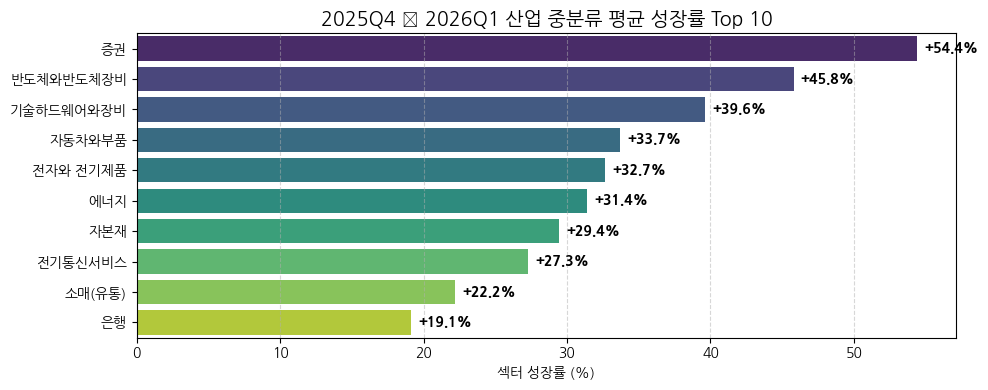

,종목명,소속 중분류,종목 성장률(%),섹터 성장률(%),초과 달성(Alpha %p)
0,미래에셋증권,증권,+183.02%,+54.41%,+128.61%p
1,한화시스템,자본재,+128.12%,+29.44%,+98.69%p
2,ISC,반도체와반도체장비,+125.02%,+45.80%,+79.22%p
3,대덕전자,기술하드웨어와장비,+81.32%,+39.63%,+41.69%p
4,현대차,자동차와부품,+66.95%,+33.71%,+33.23%p
5,엘앤에프,전자와 전기제품,+63.59%,+32.67%,+30.91%p
6,SK텔레콤,전기통신서비스,+49.35%,+27.31%,+22.04%p
7,신세계,소매(유통),+36.44%,+22.19%,+14.24%p
8,한화솔루션,에너지,+33.02%,+31.39%,+1.64%p
9,JB금융지주,은행,+20.21%,+19.13%,+1.07%p


In [22]:
plot_midlevel_analysis('2025Q4', '2026Q1')

### 💡 통합 결론: 분기별(QoQ) 주도주 추적의 이점
1. **기민한 주도주 로테이션 포착**: 연 단위(YoY) 분석으로는 뭉뚱그려지는 시황의 변화를 정확히 캐치하여 단기 자금 쏠림을 시각적으로 파악할 수 관리할 수 있습니다.
2. **최적의 단기 아웃퍼폼 포트폴리오**: 매 분기 10개의 독립적인 우상향 섹터에서 1대장씩을 선별함으로써, 지수 조정을 방어하고 초과 수익(Alpha)을 누적하는 종목 풀을 찾을 수 있습니다.
